In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
metadata_path = "../data/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10015, 7)


In [5]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

In [7]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

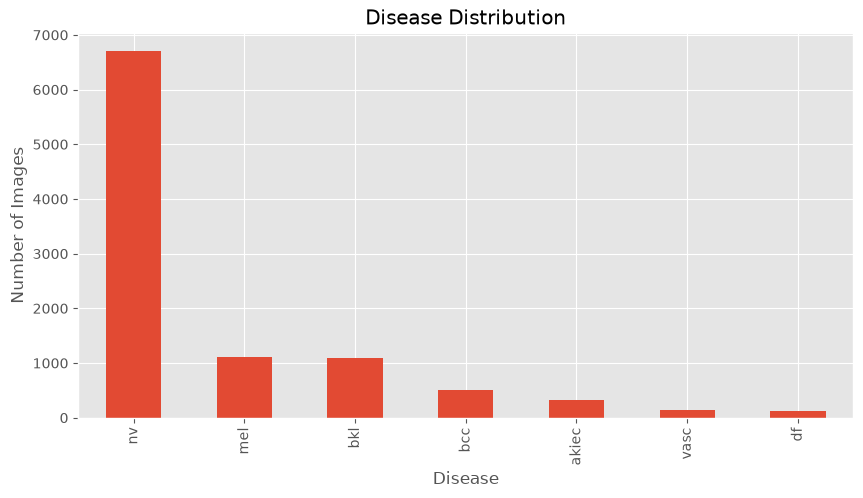

In [8]:
plt.figure(figsize=(10,5))

df["dx"].value_counts().plot(kind="bar")

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

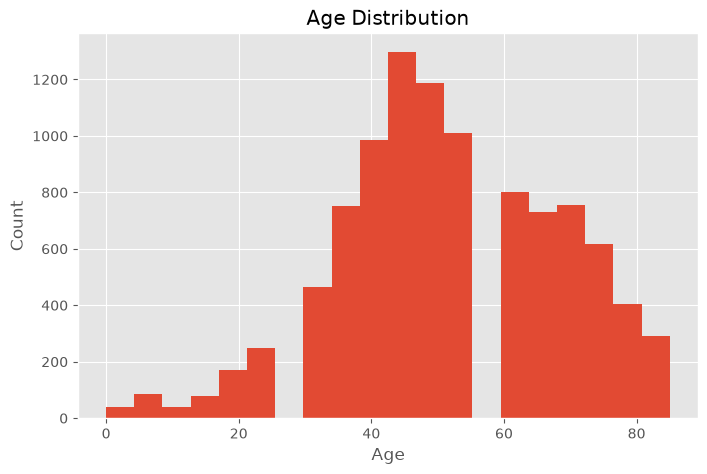

In [9]:
plt.figure(figsize=(8,5))

df["age"].hist(bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

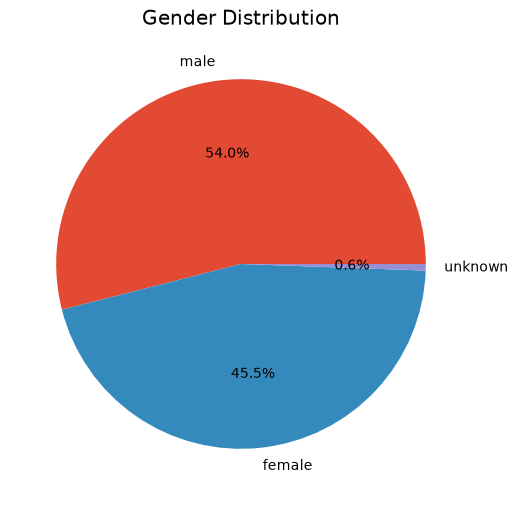

In [10]:
df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

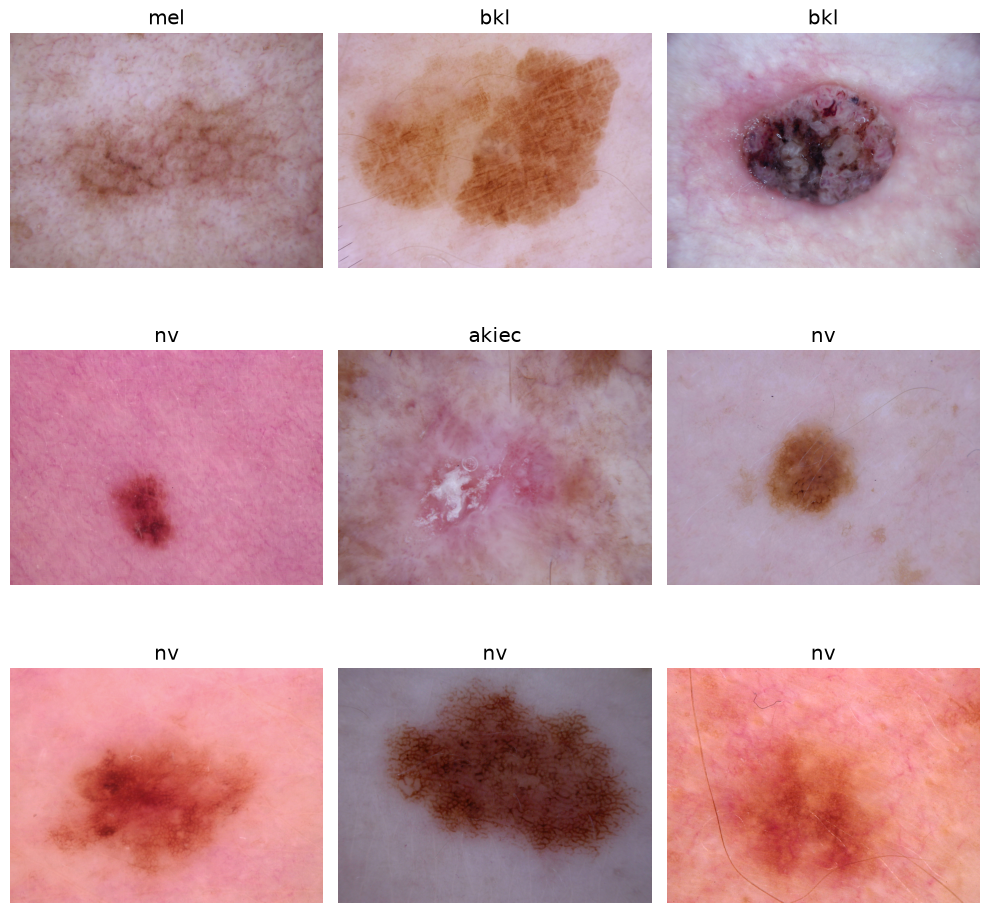

In [11]:
image_folder = "../data/HAM10000_images"

sample_images = df.sample(9)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_images.iterrows()):

    image_path = os.path.join(image_folder, row["image_id"] + ".jpg")

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(row["dx"])

    plt.axis("off")

plt.tight_layout()

plt.show()

## Observations

- The dataset contains 10,015 dermoscopic images.
- There are 7 different lesion classes.
- The dataset is highly imbalanced, with the "nv" class being the largest.
- Some patient ages are missing.
- Images vary in size and appearance, so preprocessing will be required.
- Data augmentation will help improve model generalization.

In [12]:
label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6
}

class_names = [
    "Actinic Keratosis",
    "Basal Cell Carcinoma",
    "Benign Keratosis",
    "Dermatofibroma",
    "Melanoma",
    "Melanocytic Nevus",
    "Vascular Lesion"
]

In [13]:
import os

image_folder = "../data/HAM10000_images"

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_folder, x + ".jpg")
)

df["label"] = df["dx"].map(label_map)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images\ISIC_0027419.jpg,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images\ISIC_0025030.jpg,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images\ISIC_0026769.jpg,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images\ISIC_0025661.jpg,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images\ISIC_0031633.jpg,2


In [15]:
df.to_csv("../data/processed_metadata.csv", index=False)